In [2]:
#CMIP6 File Running. Much of the same deal
import os
import sys


In [3]:
!python3 -m pip install pandas


In [4]:
#Importing stuff for graphs 
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import netCDF4 
import dask 
import regionmask 
import scipy

In [5]:
#Data sets for 2.6, 4.5, 8.5

ds_26 = xr.open_dataset("/Users/katrishka_kipp/Downloads/9d45d0ec5e219d54ed2187e4fbce4728/ssp126_20250116-21001216.nc")
ds_45 = xr.open_dataset("/Users/katrishka_kipp/Downloads/4acdfe38e474ce191b3cf785f3dc39ce/ssp245_20250116-21001216.nc")
ds_85 = xr.open_dataset("/Users/katrishka_kipp/Downloads/3ed2227bdf1f38cf0b90de561b96de1a/ssp585_20250116-21001216.nc")

In [6]:
print(ds_26)


<xarray.Dataset> Size: 74MB
Dimensions:             (time: 912, bnds: 2, j: 33, i: 36, vertices: 4)
Coordinates:
  * time                (time) datetime64[ns] 7kB 2025-01-16T12:00:00 ... 210...
  * j                   (j) int32 132B 46 47 48 49 50 51 ... 73 74 75 76 77 78
  * i                   (i) int32 144B 192 193 194 195 196 ... 224 225 226 227
    latitude            (j, i) float64 10kB ...
    longitude           (j, i) float64 10kB ...
    type                |S7 7B ...
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) datetime64[ns] 15kB ...
    vertices_latitude   (time, j, i, vertices) float64 35MB ...
    vertices_longitude  (time, j, i, vertices) float64 35MB ...
    siconc              (time, j, i) float32 4MB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   60265.0
    branch_time_in_parent:  60265.0

In [7]:
SIC26 = ds_26['siconc']

sim_26=SIC26.isel(i= slice(50, 300), j=slice(50,300)) 

near = ds_26["siconc"].sel(time=slice("2025-01-01","2040-12-31")).mean(dim="time")

mid = ds_26["siconc"].sel(time=slice("2041-01-01","2070-12-31")).mean(dim="time")

late = ds_26["siconc"].sel(time=slice("2071-01-01","2100-12-31")).mean(dim="time")

datasets = [near, mid, late]

<class 'cartopy.mpl.geoaxes.GeoAxes'>


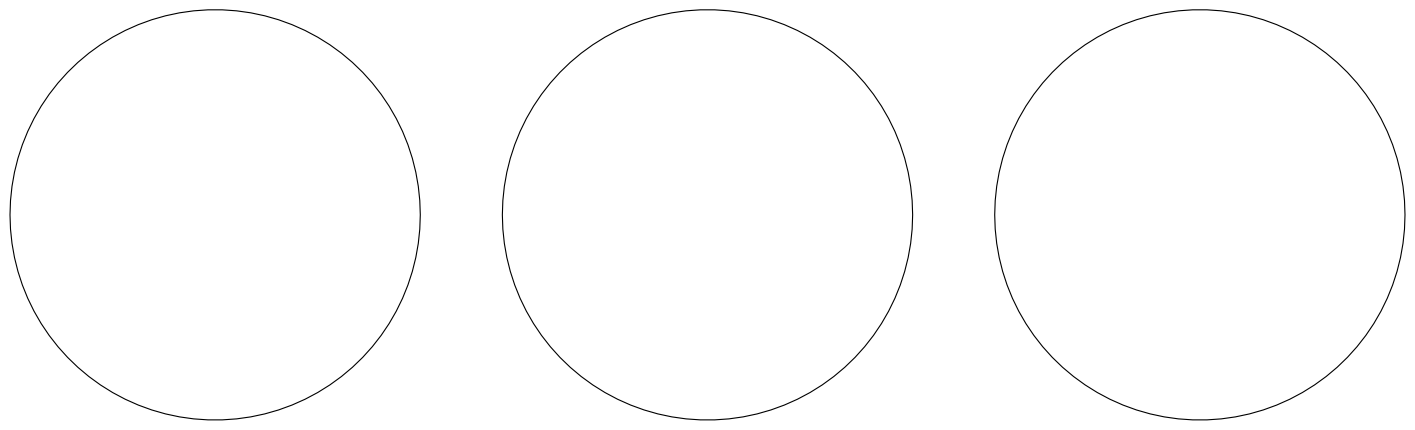

In [8]:
#Create maps
proj = ccrs.NorthPolarStereo()

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6),
    subplot_kw={"projection": proj}
)

print(type(axes[0]))

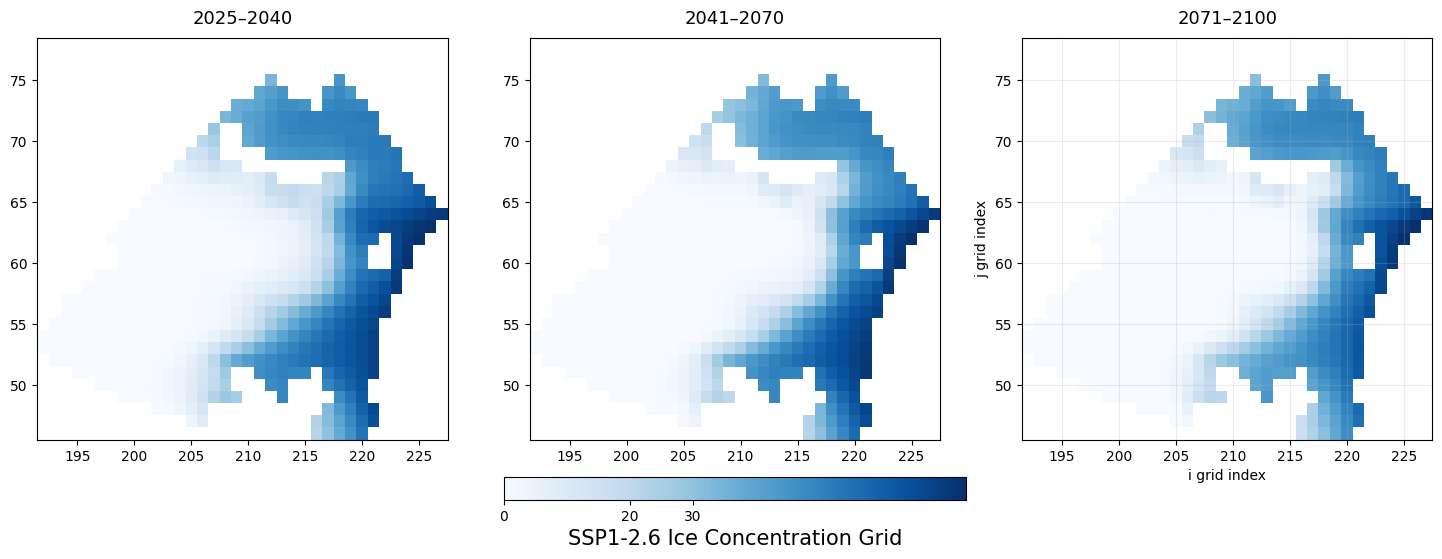

In [9]:
#Plotting! Do it 3 times
titles = ["2025–2040", "2041–2070", "2071–2100"] 

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, data, title in zip(axes, datasets, titles):
  data=data.squeeze()
  ax.set_title(title, fontsize=13, pad=10)
  im = ax.pcolormesh(
  ds_26["i"],
  ds_26["j"],
  data,
  cmap="Blues",
  shading = 'auto'
)  
  
ax.set_xlabel(title)
ax.set_ylabel(title)
ax.set_xlabel("i grid index")
ax.set_ylabel("j grid index")
ax.grid(alpha=0.25)

cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08
)
cbar.set_label("SSP1-2.6 Ice Concentration Grid", fontsize=15)
cbar.set_ticks([0, 20, 30])

plt.show()

In [10]:
SIC45 = ds_45['siconc']

near4 = ds_45["siconc"].sel(time=slice("2025-01-01","2040-12-31")).mean(dim="time")
mid4 = ds_45["siconc"].sel(time=slice("2041-01-01","2070-12-31")).mean(dim="time")
late4 = ds_45["siconc"].sel(time=slice("2071-01-01","2100-12-31")).mean(dim="time")

datasets_2 = [near4, mid4, late4]
titles = ["2025–2040", "2041–2070", "2071–2100"]

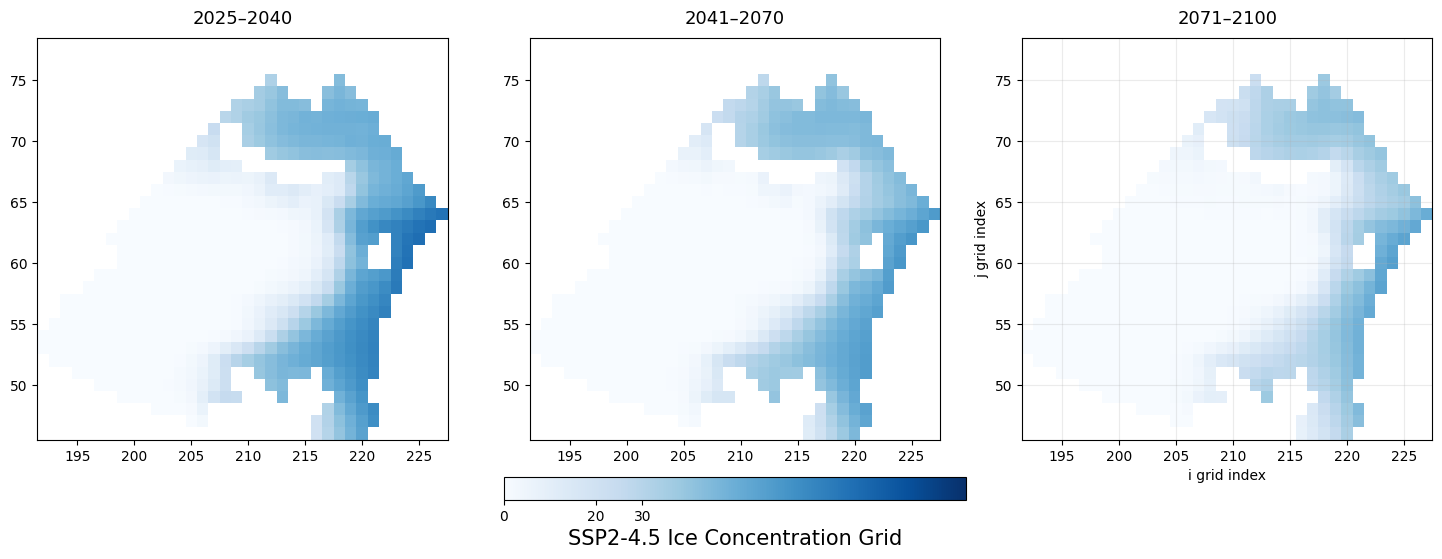

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = ["2025–2040", "2041–2070", "2071–2100"]

for ax, data, title in zip(axes, datasets_2, titles):
  data=data.squeeze()
  ax.set_title(title, fontsize=13, pad=10)
  im = ax.pcolormesh(
  ds_45["i"],
  ds_45["j"],
  data,
  cmap="Blues",
  shading = 'auto',
  vmin =0,
  vmax=100
)  
  
ax.set_xlabel(title)
ax.set_ylabel(title)
ax.set_xlabel("i grid index")
ax.set_ylabel("j grid index")
ax.grid(alpha=0.25)

cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08
)
cbar.set_label("SSP2-4.5 Ice Concentration Grid", fontsize=15)
cbar.set_ticks([0, 20, 30])

plt.show()

In [12]:
SIC85 = ds_85['siconc']
sim_85=SIC85.isel(i= slice(50, 300), j=slice(50,300)) 

near8 = ds_85["siconc"].sel(time=slice("2025-01-01","2040-12-31")).mean(dim="time")

mid8 = ds_85["siconc"].sel(time=slice("2041-01-01","2070-12-31")).mean(dim="time")

late8 = ds_85["siconc"].sel(time=slice("2071-01-01","2100-12-31")).mean(dim="time")

datasets_3 = [near8, mid8, late8]
titles = ["2025–2040", "2041–2070", "2071–2100"]

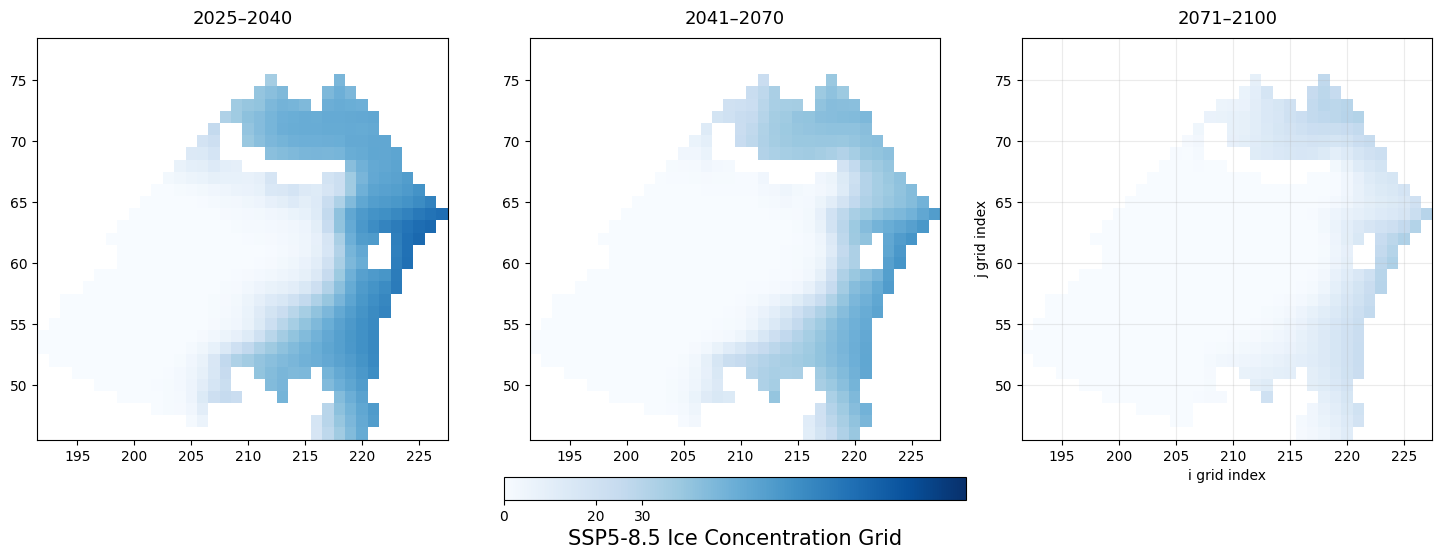

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = ["2025–2040", "2041–2070", "2071–2100"]

for ax, data, title in zip(axes, datasets_3, titles):
  data=data.squeeze()
  ax.set_title(title, fontsize=13, pad=10)
  im = ax.pcolormesh(
  ds_45["i"],
  ds_45["j"],
  data,
  cmap="Blues",
  shading = 'auto',
  vmin =0,
  vmax=100
)  
  
ax.set_xlabel(title)
ax.set_ylabel(title)
ax.set_xlabel("i grid index")
ax.set_ylabel("j grid index")
ax.grid(alpha=0.25)

cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08
)
cbar.set_label("SSP5-8.5 Ice Concentration Grid", fontsize=15)
cbar.set_ticks([0, 20, 30])

plt.show()